In [5]:
from langchain_core.tools import tool
from langgraph.types import interrupt
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_google_credentials,
)
from langgraph.types import interrupt

from langchain_google_community.gmail.search import GmailSearch
from langchain_google_community.gmail.send_message import GmailSendMessage

# OAuth: credentials.json comes from Google Cloud Console (Desktop app client).
# token.json is created on first run after you approve access in the browser.
credentials = get_google_credentials(
    token_file="token.json",
    scopes=["https://mail.google.com/"],
    client_secrets_file="credentials.json",
)
api_resource = build_resource_service(credentials=credentials)

_gmail_search = GmailSearch(api_resource=api_resource)
_gmail_send = GmailSendMessage(api_resource=api_resource)


@tool
def read_gmail(query: str, max_results: int = 5) -> list:
    """Read emails from Gmail. `query` uses Gmail search syntax,
    e.g. 'is:unread', 'from:someone@example.com', 'subject:invoice'.
    Returns id, subject, sender, date, snippet and body for each match."""
    return _gmail_search.invoke(
        {"query": query, "max_results": max_results, "resource": "messages"}
    )



@tool
def send_gmail(to: str, subject: str, message: str) -> str:
    """Send an email via Gmail. `to` can be a single address or
    comma-separated addresses. Requires human approval before sending."""
    recipients = [addr.strip() for addr in to.split(",")]

    # Pause here and surface the draft to the human
    decision = interrupt({
        "action": "send_gmail",
        "to": recipients,
        "subject": subject,
        "message": message,
        "question": "Approve sending this email?",
    })

    if decision.get("type") == "approve":
        pass
    elif decision.get("type") == "edit":
        # Human supplies modified fields
        recipients = decision.get("to", recipients)
        subject = decision.get("subject", subject)
        message = decision.get("message", message)
    else:
        return "Email NOT sent: the user rejected it."

    return _gmail_send.invoke(
        {"to": recipients, "subject": subject, "message": message}
    )

tools = [read_gmail, send_gmail]

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=944149109270-2uhmghtrbc9obcavas4d68tult6j3ktr.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A64769%2F&scope=https%3A%2F%2Fmail.google.com%2F&state=R6bmFutnpdvONwVWLhdN75ldaOZi08&code_challenge=ezPOEpTfJBZCK02sT2iHuw1YiPvQw873mJ0N06vm7rg&code_challenge_method=S256&access_type=offline


C:\Users\SUBHAM\AppData\Local\Temp\ipykernel_20948\4060204416.py:19: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [7]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [9]:
load_dotenv()

llm=ChatGroq(model="openai/gpt-oss-120b")

In [10]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [11]:
llm_with_tools=llm.bind_tools(tools)

In [21]:
from langchain_core.messages import SystemMessage
from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import InMemorySaver

tools = [read_gmail, send_gmail]
llm_with_tools = llm.bind_tools(tools)


from langchain_core.messages import SystemMessage

SYSTEM_PROMPT = SystemMessage(
    "You are an email assistant with tools to read and send Gmail. "
    "When the user asks you to send an email, call the send_gmail tool immediately "
    "with the details given. Do NOT ask for confirmation in chat: the tool itself "
    "asks the user for approval before anything is sent. "
    "If the body is not specified, write a short, polite one yourself."
)

def chat_node(state: State):
    response = llm_with_tools.invoke([SYSTEM_PROMPT] + state["messages"])
    return {"messages": [response]}

tool_node = ToolNode(tools)

builder = StateGraph(State)
builder.add_node("chat_node", chat_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges(
    "chat_node",
    tools_condition,
    {"tools": "tool_node", "__end__": "__end__"},
)
builder.add_edge("tool_node", "chat_node")

graph = builder.compile(checkpointer=InMemorySaver())

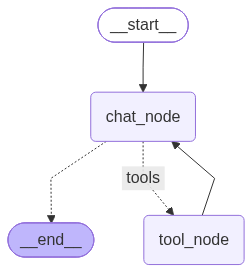

In [22]:
graph

In [23]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "email-1"}}

In [24]:
result = graph.invoke(
    {"messages": [("user", "Send an email to subhampadhi33537@gmail.com with subject 'Report' saying the report is ready")]},
    config,
)

In [25]:
if "__interrupt__" in result:
    print(result["__interrupt__"][0].value)

{'action': 'send_gmail', 'to': ['subhampadhi33537@gmail.com'], 'subject': 'Report', 'message': 'The report is ready.', 'question': 'Approve sending this email?'}


In [26]:
result = graph.invoke(Command(resume={"type": "approve"}), config)

In [27]:
print(result["messages"][-1].content)

Your email has been sent. Let me know if there's anything else you need!


In [33]:
from langgraph.types import Command

config = {"configurable": {"thread_id": "email-chat-2"}}
IN_JUPYTER = True  # Jupyter doesn't echo input(), so we print it ourselves. Set False in a terminal.


def handle_interrupts(result):
    """Keep asking the human until no interrupt is pending."""
    while "__interrupt__" in result:
        draft = result["__interrupt__"][0].value

        print("\n" + "─" * 45)
        print("⚠️  Approval needed")
        print(f"📬 To:      {', '.join(draft['to'])}")
        print(f"📝 Subject: {draft['subject']}")
        print(f"💬 Body:    {draft['message']}")
        print("─" * 45)

        choice = input("👉 approve / edit / reject: ").strip().lower()
        if IN_JUPYTER:
            print(f"👉 Your choice: {choice}")

        if choice in ("approve", "a", "y", "yes"):
            resume = {"type": "approve"}
        elif choice in ("edit", "e"):
            resume = {"type": "edit"}
            new_to = input("✏️  New recipient (Enter to keep): ").strip()
            new_subject = input("✏️  New subject (Enter to keep): ").strip()
            new_body = input("✏️  New body (Enter to keep): ").strip()
            if new_to:
                resume["to"] = [a.strip() for a in new_to.split(",")]
            if new_subject:
                resume["subject"] = new_subject
            if new_body:
                resume["message"] = new_body
        else:
            resume = {"type": "reject"}

        result = graph.invoke(Command(resume=resume), config)

    return result


def print_new_messages(messages, start):
    """Print only the messages added during this turn."""
    for m in messages[start:]:
        if m.type == "human":
            continue
        elif m.type == "ai":
            for tc in m.tool_calls or []:
                print(f"\n🔧 AI is calling tool: {tc['name']}")
            if m.content:
                print(f"\n🤖 AI: {m.content}")
        elif m.type == "tool":
            icon = "❌" if "NOT sent" in str(m.content) else "✅"
            print(f"\n{icon} Tool [{m.name}]: {str(m.content)[:300]}")


print("💌 Email assistant ready. Type 'exit' to quit.")

while True:
    user_input = input("\n🧑 Human: ").strip()
    if IN_JUPYTER:
        print(f"\n🧑 Human: {user_input}")

    if user_input.lower() in ("exit", "quit", "q"):
        print("\n👋 Bye!")
        break
    if not user_input:
        continue

    # How many messages does this thread already have?
    snapshot = graph.get_state(config)
    before = len(snapshot.values.get("messages", []))

    result = graph.invoke({"messages": [("user", user_input)]}, config)
    result = handle_interrupts(result)

    # +1 skips the human message we just added
    print_new_messages(result["messages"], before + 1)

💌 Email assistant ready. Type 'exit' to quit.

🧑 Human: hii

🤖 AI: Hello! It looks like you’re just saying hi. How can I assist you with your email today? Let me know if you’d like to read, draft, or send a message.

🧑 Human: who are you?

🤖 AI: I’m your personal email assistant. I can read your Gmail messages, draft replies, and send new emails for you—all right from this chat. Just tell me what you need, and I’ll take care of the rest!

🧑 Human: what is my last 2 mails just tell me who sent me

🔧 AI is calling tool: read_gmail

✅ Tool [read_gmail]: [{"id": "1a1070df3355fb28", "threadId": "1a1070df3355fb28", "snippet": "Hello, I hope you&#39;re doing well. I wanted to share a brief note about the exciting developments in artificial intelligence (AI) and how it&#39;s shaping many industries. If you&#39;d like to", "body": "", "subject": "Discuss

🤖 AI: Your two most recent emails were both sent by **Subham <subham33537@gmail.com>**.

🧑 Human: who send me?

🤖 AI: Your most recent email 